<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/notebooks/Getting_Started_with_Image_Classification_PyTorch_wandb_and_FiftyOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pet Breed Classification - Getting Started with Image Classification in  PyTorch and FiftyOne

#### Author: Antonio Rueda-Toicen

**antonio.rueda.toicen 'at' hpi 'dot' de**


[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

Approaches for Image Classification: Fully Supervised vs Zero Shot

This notebook shows how to recognize different breeds of cats and dogs.

We'll use a collection of pet images and a fine-tuned PyTorch neural network (a [ResNet 18](https://arxiv.org/abs/1512.03385)) to identify them.

**Here's what we'll do:**

1. **Get the images:** We'll use a dataset called "Oxford-IIIT Pets" which contains many pictures of cats and dogs.
2. **Prepare the images:** We'll make sure the images are in the right format for the neural network to process.
3. **Train the network:** We'll use a special type of program called a "neural network" to train the computer to recognize the pets.
4. **Test the network:** We'll see how well the computer can identify new pet images it hasn't seen before.
5. **Explore the results:** We'll use the open source FiftyOne app to visualize the predictions and understand deeper both the neural network and the image dataset.
6. **Compare the out of training distribution (OOD) results with those obtained from a CLIP model**: Zero-shot classification with vision-language foundation models (e.g. [CLIP](https://arxiv.org/abs/2103.00020)) is a powerful tool for image labeling. We will introduce the technique near the end of this notebook and go deeper into it in future sessions.



## The Oxford pets dataset

The [Oxford-IIIT pets dataset by O. M. Parkhi, A. Vedaldi, A. Zisserman, C. V. Jawahar
](https://www.robots.ox.ac.uk/~vgg/data/pets/) is a 37 category pet dataset with roughly 200 images for each class. Each class corresponds to a breed of cat or dog. The dataset includes annotations for classification, semantic segmentation and object detection. In this notebook, we will focus on image classification and use the [version of the dataset available on PyTorch datasets](https://pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html).

In [1]:
# These are the breeds of dogs and cats considered in the Oxford-IIT pets dataset
oxford_pets_classes = [
    ("Abyssinian", "cat"),
    ("American Bulldog", "dog"),
    ("American Pit Bull Terrier", "dog"),
    ("Basset Hound", "dog"),
    ("Beagle", "dog"),
    ("Bengal", "cat"),
    ("Birman", "cat"),
    ("Bombay", "cat"),
    ("Boxer", "dog"),
    ("British Shorthair", "cat"),
    ("Chihuahua", "dog"),
    ("Egyptian Mau", "cat"),
    ("English Cocker Spaniel", "dog"),
    ("English Setter", "dog"),
    ("German Shorthaired", "dog"),
    ("Great Pyrenees", "dog"),
    ("Havanese", "dog"),
    ("Japanese Chin", "dog"),
    ("Keeshond", "dog"),
    ("Leonberger", "dog"),
    ("Maine Coon", "cat"),
    ("Miniature Pinscher", "dog"),
    ("Newfoundland", "dog"),
    ("Persian", "cat"),
    ("Pomeranian", "dog"),
    ("Pug", "dog"),
    ("Ragdoll", "cat"),
    ("Russian Blue", "cat"),
    ("Saint Bernard", "dog"),
    ("Samoyed", "dog"),
    ("Scottish Terrier", "dog"),
    ("Shiba Inu", "dog"),
    ("Siamese", "cat"),
    ("Sphynx", "cat"),
    ("Staffordshire Bull Terrier", "dog"),
    ("Wheaten Terrier", "dog"),
    ("Yorkshire Terrier", "dog")
]

## Install fiftyone and wandb

In [2]:
%%capture
!uv pip install fiftyone==1.9.0 wandb==0.22.2

In [3]:
# Check fiftyone install
import fiftyone as fo
fo.__version__

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


'1.9.0'

In [4]:
# Check wandb install
import wandb
wandb.__version__

'0.22.2'

## Library imports

In [5]:
import os
import io
import random
import numpy as np
import pandas as pd
import skimage.io as io
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from google.colab import userdata
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from torchvision import models
from torchvision.datasets import OxfordIIITPet
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor



## Get wandb API key from Google Colab

In [6]:
os.environ['WANDB_API_KEY'] = userdata.get('wandb_api')

## Define wandb project

In [7]:
project="pets-classification"
# https://docs.wandb.ai/guides/track/tracking-faq#initstarterror-error-communicating-with-wandb-process-
wandb.init(settings=wandb.Settings(start_method="fork"), project=project)

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: antonioernestoruedatoicen (antonios-org) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Seeding for reproducibility

In [8]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Understanding Random Seed Setting in PyTorch

## What the Code Does

```python
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
```

This function makes our training experiment repeatable by controlling all the parts of our code that normally use randomness. Think of it like setting the starting point for all random choices our program will make.

| Component | Purpose |
|-----------|---------|
| `random.seed()` | Sets Python's built-in random module seed |
| `PYTHONHASHSEED` | Controls hash randomization in Python |
| `np.random.seed()` | Sets NumPy's random number generator seed |
| `torch.manual_seed()` | Sets PyTorch's CPU-based random generators |
| `torch.cuda.manual_seed()` | Sets PyTorch's GPU-based random generators |
| `cudnn.deterministic = True` | Makes cuDNN operations deterministic |
| `cudnn.benchmark = False` | Disables cuDNN auto-tuner optimization |

## Why It Matters

In deep learning, randomness affects many processes:
- Weight initialization
- Batch sampling order
- Data augmentation
- Dropout behavior

Setting fixed seeds ensures:
- Reproducible results across runs
- Easier debugging
- Fair model comparisons
- Reliable research findings

The trade-off is potentially slightly lower performance, as some non-deterministic optimizations are disabled.

### What non-deterministic operations are disabled?

When we set `torch.backends.cudnn.deterministic = True` and `torch.backends.cudnn.benchmark = False`, we're disabling several non-deterministic optimizations that would otherwise improve performance. Here's what gets disabled:

1. **cuDNN Auto-Tuner**: When `cudnn.benchmark = False`, PyTorch disables the cuDNN auto-tuner, which normally:
   - Benchmarks multiple convolution algorithms at the beginning of training
   - Dynamically selects the fastest algorithm for our specific hardware and input dimensions
   - Adapts to different input sizes by finding optimal algorithms for each

2. **Parallel Algorithm Selection**: cuDNN normally can choose from multiple implementations of the same operation based on runtime conditions, potentially using:
   - Different memory access patterns
   - Hardware-specific optimizations
   - Concurrent execution strategies

3. **Dynamic Memory Management**: Some memory optimizations that dynamically reallocate or reuse memory in ways that can vary between runs are constrained.

4. **Asynchronous Execution Patterns**: Non-deterministic scheduling of operations across CPU/GPU that might complete in different orders between runs.

5. **Sub-optimal Convolution Algorithms**: Instead of using the fastest algorithm, PyTorch will use deterministic algorithms which may be slower but guarantee the same results every time.

The performance impact varies widely depending on our model architecture and hardware, but typically ranges from negligible to around 10-15% slowdown in training time. For models with many convolution operations, the impact can be more significant.

For day-to-day experimentation, we might want to enable determinism only when debugging or for final result verification, then use the optimized settings for regular training.

## Check availability of GPU

In [9]:
# Check for GPU availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Initialize wandb

In [10]:
config = {
               "architecture": "resnet18",
               "dataset": "Oxford-IIIT Pet Dataset from torchvision.datasets",
               "learning_rate": 0.001,
               "epochs": 10,
               "batch_size": 32,
               "optimizer": "Adam",
               "scheduler": "OneCycleLR",
               "loss_function": "CrossEntropyLoss"
           }

In [11]:
# We use this to start wandb and specify the project that logs our experiments
wandb.init(project='dsr-pets-breed-classification-oxford-dataset',
           # Name of the run inside the project, if left empty it will be a randomly generated name
           # name='supervised-learning',
           # config has the hyperparameters that give a brief overview of what we are doing
           config=config)

## Define data transformations

In [12]:
# Data Preparation
# Define transformations applied to all sets during training and evaluation with DataLoaders
# These transformations are to be applied 'on the fly', ideally these would be persisted on disk
# before training and evaluation, so that we can carefully explore the datasets, their relationships with one another
# and the model's performance

# We apply Imagenet normalization on all sets (train, test, and val)

# We do data augmentation in the training set only
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # Random transformations should only be applied on the training set
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    #
    transforms.ToImage(),
    # ToDtype turns the uint8 tensors to torch.float32 range
    # and scales them in the range [0.0, 1.0] by dividing all intensities with 255.
    transforms.ToDtype(torch.float32, scale=True),
    # This applies the standard scaler considering the Imagenet stats for R, G, B intensities
    # We need to do this because we are doing transfer learning, we are going to be using
    # an Imagenet pretrained model and we benefit from making our R, G, B intensities be in the same scale
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# The transformations that we apply in the validation and test sets
# are meant to keep evaluations of cross entropy loss and performance metrics consisten
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [13]:
# Load the dataset
print("Loading Oxford-IIIT Pet Dataset...")
data_root = './data'
os.makedirs(data_root, exist_ok=True)

# Download the dataset
train_dataset = OxfordIIITPet(root=data_root, split='trainval', download=True, transform=train_transforms)
test_dataset = OxfordIIITPet(root=data_root, split='test', download=True, transform=val_test_transforms)

# Check sizes
len(train_dataset), len(test_dataset)

Loading Oxford-IIIT Pet Dataset...


100%|██████████| 792M/792M [00:44<00:00, 17.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.37MB/s]


(3680, 3669)

In [14]:
# Split train dataset into train and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

## Transformations for validation set

In [15]:
# Override transform for validation dataset
# It had been assigned the transformation assigned to the training set
val_dataset.dataset.transform = val_test_transforms

## Create DataLoaders

In [16]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 2944
Validation samples: 736
Testing samples: 3669


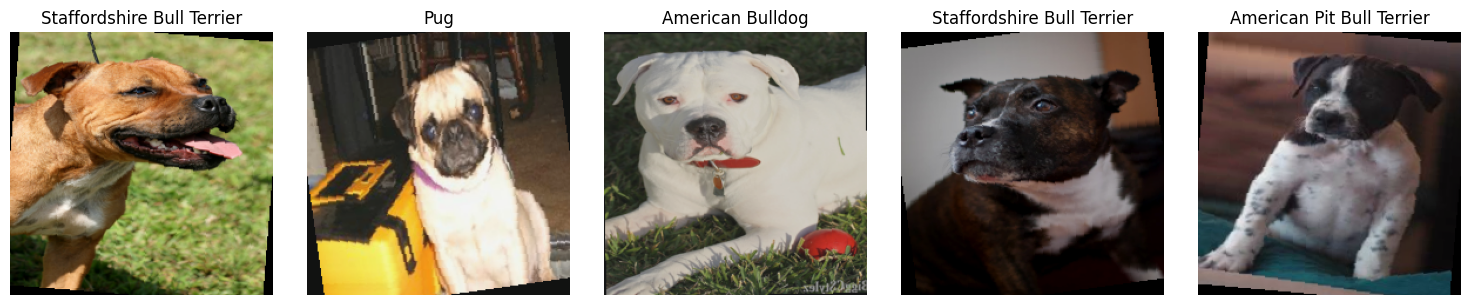

In [17]:
# Display some sample images
def display_sample_images(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Denormalize
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"{oxford_pets_classes[label][0]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

display_sample_images(train_dataset)

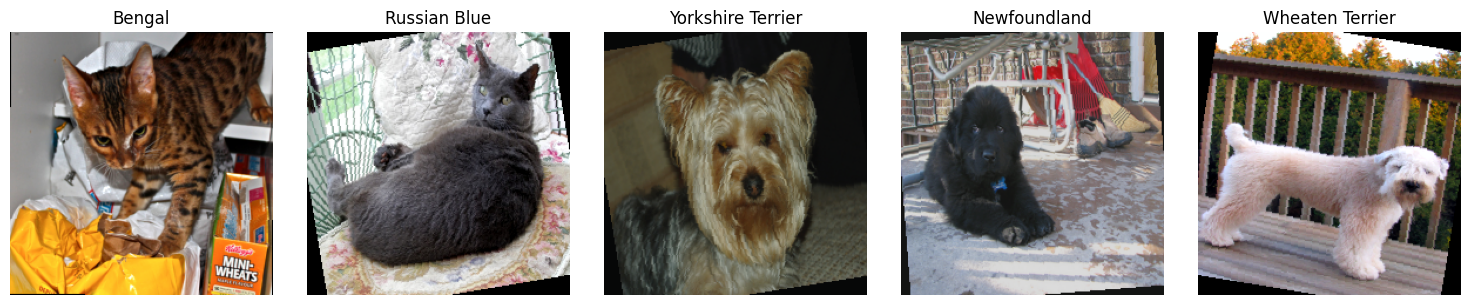

In [18]:
display_sample_images(val_dataset)

## Define a ResNet18 as the pretrained model

In [19]:
# Model definition
class PetClassifier(nn.Module):
    def __init__(self, num_classes=37):
        super(PetClassifier, self).__init__()
        # Load a pre-trained ResNet18 model
        self.backbone = models.resnet18(weights='IMAGENET1K_V1')

        # Freeze the early layers
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False

        # Replace the final fully connected layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(num_features, 256),  # New hidden layer with 256 units
            nn.ReLU(),  # Activation function for the hidden layer
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)  # Output layer
        )

    def forward(self, x):
        return self.backbone(x)

# Initialize the model
model = PetClassifier(num_classes=37).to(device)
# Check the architecture of the model
model




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 248MB/s]


PetClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

## Define the loss function and variant of stochastic gradient descent

In [20]:
criterion = nn.CrossEntropyLoss()
initial_learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=initial_learning_rate)


## Define a scheduler for the learning rate

### OneCycleLR: A Dynamic Learning Rate Scheduler

[OneCycleLR](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.OneCycleLR.html) is a learning rate scheduler that varies the learning rate during training, following a specific pattern:

1. **Warm-up:** The learning rate starts low and gradually increases to a maximum value (`max_lr`).
2. **Annealing:** After reaching the maximum, the learning rate gradually decreases to a very small value.

**Benefits:**

- **Faster Convergence:**  Helps models train faster and reach good results in fewer epochs.
- **Improved Generalization:** Can lead to better performance on unseen data by preventing overfitting.
- **Reduced Tuning:** Often requires less hyperparameter tuning compared to other schedulers.

**Key Hyperparameter:** `max_lr` (the maximum learning rate) needs to be tuned for optimal performance.

In [21]:
num_epochs = 5
scheduler = OneCycleLR(optimizer, max_lr=0.01, total_steps=len(train_loader)*num_epochs)

## Training loop

In [22]:
# Training loop
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## Evaluation

In [23]:
# Validation/Testing function
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, cm, all_preds, all_labels

## Running the training loop

In [24]:
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Train one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on validation set
    val_loss, val_acc, val_precision, val_recall, val_cm, _, _ = evaluate(model, val_loader, criterion, device)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Log metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "learning_rate": optimizer.param_groups[0]['lr']
    })


    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save locally
        torch.save(model.state_dict(), 'best_model.pth')
        # Save to wandb
        wandb.save('best_model.pth')
        print("Saved best model locally and to wandb!")

Epoch 1/5


Evaluating: 100%|██████████| 23/23 [00:01<00:00, 13.98it/s]


Train Loss: 1.9426, Train Acc: 0.5071
Val Loss: 0.7219, Val Acc: 0.7772, Val Precision: 0.8220, Val Recall: 0.7772
Saved best model locally and to wandb!
Epoch 2/5


Evaluating: 100%|██████████| 23/23 [00:01<00:00, 11.88it/s]


Train Loss: 0.6164, Train Acc: 0.8247
Val Loss: 0.5962, Val Acc: 0.8166, Val Precision: 0.8335, Val Recall: 0.8166
Saved best model locally and to wandb!
Epoch 3/5


...

Train Loss: 0.3774, Train Acc: 0.8849
Val Loss: 0.6128, Val Acc: 0.8043, Val Precision: 0.8330, Val Recall: 0.8043
Epoch 4/5


Evaluating: 100%|██████████| 23/23 [00:01<00:00, 13.94it/s]


Train Loss: 0.2545, Train Acc: 0.9290
Val Loss: 0.6608, Val Acc: 0.8084, Val Precision: 0.8390, Val Recall: 0.8084
Epoch 5/5


Evaluating: 100%|██████████| 23/23 [00:01<00:00, 11.67it/s]


Train Loss: 0.2202, Train Acc: 0.9368
Val Loss: 0.5942, Val Acc: 0.8397, Val Precision: 0.8592, Val Recall: 0.8397
Saved best model locally and to wandb!


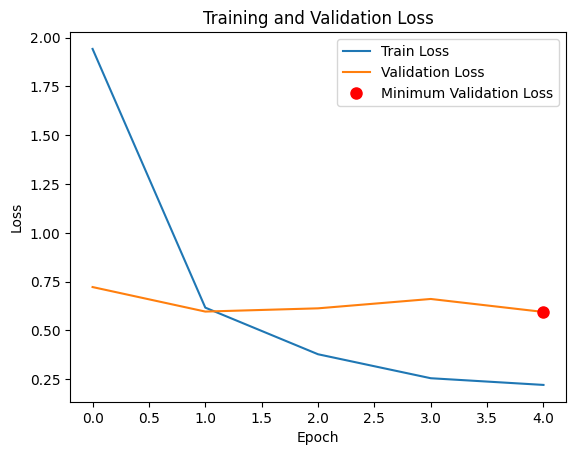

In [25]:
# After the training loop:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

# Find the epoch with the lowest validation loss
min_val_loss_epoch = np.argmin(val_losses)

# Highlight the minimum validation loss point
plt.plot(min_val_loss_epoch, val_losses[min_val_loss_epoch], 'ro', markersize=8,
         label='Minimum Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Test Set Evaluation

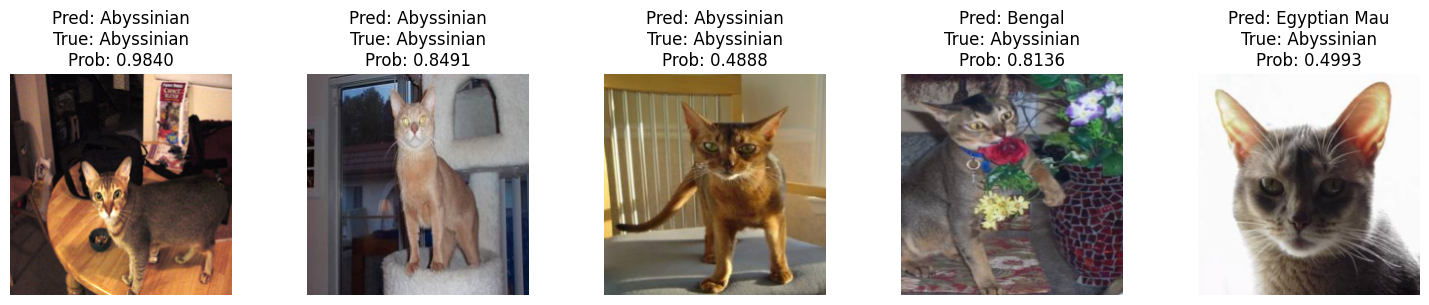

In [26]:
# Assuming you have the test_loader, model, and oxford_pets_classes

def display_batch_predictions(model, test_loader, oxford_pets_classes, batch_size=5):
    """Displays predictions for a batch of images from the test set."""

    # Get a batch of data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)  # Move inputs to the device

    # Get model predictions
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted_classes = torch.max(outputs, 1)

    # Display predictions
    fig, axes = plt.subplots(1, batch_size, figsize=(15, 3))
    for i in range(batch_size):
        img = inputs[i].cpu().permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]) # Denormalize
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {oxford_pets_classes[predicted_classes[i].item()][0]}\n"
                          f"True: {oxford_pets_classes[labels[i].item()][0]}\n"
                          f"Prob: {probabilities[i][predicted_classes[i].item()].item():.4f}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display predictions
display_batch_predictions(model, test_loader, oxford_pets_classes)

Evaluating on test set...


Evaluating: 100%|██████████| 115/115 [00:05<00:00, 19.85it/s]


Test Loss: 0.7899, Test Acc: 0.7732
Test Precision: 0.8040, Test Recall: 0.7732


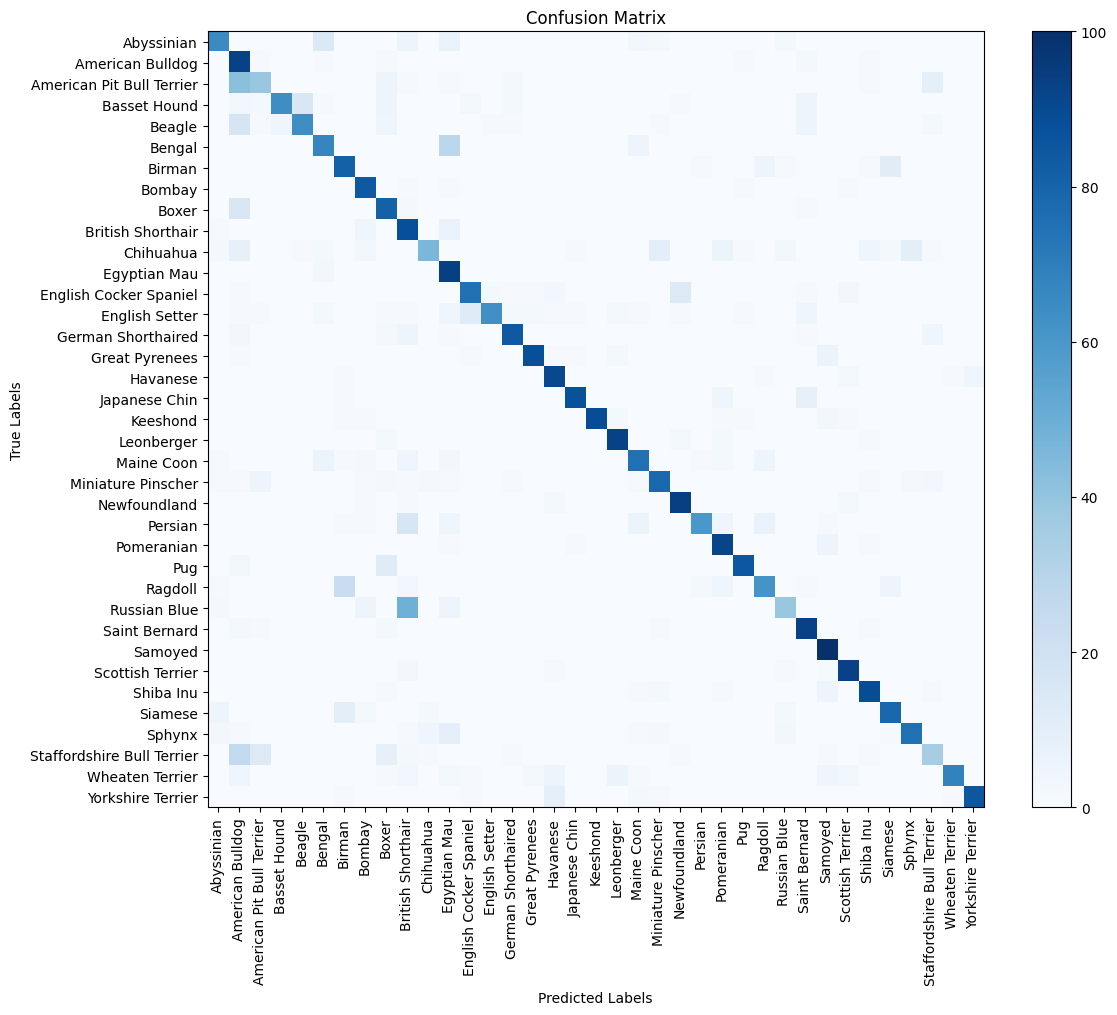

In [27]:
# Evaluate on test set
print("Evaluating on test set...")
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc, test_precision, test_recall, test_cm, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")

# Log final test results to W&B
wandb.log({
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_precision": test_precision,
    "test_recall": test_recall
})


# Get only the breed names from oxford_pets_classes
breed_labels = [breed for breed, _ in oxford_pets_classes]

# Display confusion matrix with breed labels
plt.figure(figsize=(12, 10))
plt.imshow(test_cm, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(breed_labels)), breed_labels, rotation=90)  # Set breed labels for x-axis
plt.yticks(np.arange(len(breed_labels)), breed_labels)  # Set breed labels for y-axis
plt.tight_layout()
plt.show()

In [28]:
# Create a readable report
class_report = classification_report(test_labels, test_preds, output_dict=True)
class_metrics = pd.DataFrame(class_report).transpose()

# Extract breed names from oxford_pets_classes
breed_names = [breed for breed, _ in oxford_pets_classes]

# Add a new column 'breed' to the DataFrame
class_metrics['breed'] = breed_names + ['accuracy', 'macro avg', 'weighted avg']
# The last 3 elements of class_metrics.index are 'accuracy', 'macro avg', 'weighted avg'

# Set the 'breed' column as the index
class_metrics.set_index('breed', inplace=True)
class_metrics

,precision,recall,f1-score,support
breed,,,,
Abyssinian,0.802469,0.663265,0.726257,98.000000
American Bulldog,0.420814,0.930000,0.579439,100.000000
American Pit Bull Terrier,0.619048,0.390000,0.478528,100.000000
Basset Hound,0.941176,0.640000,0.761905,100.000000
Beagle,0.800000,0.640000,0.711111,100.000000
Bengal,0.697917,0.670000,0.683673,100.000000
Birman,0.675000,0.810000,0.736364,100.000000
Bombay,0.807692,0.954545,0.875000,88.000000
Boxer,0.637795,0.818182,0.716814,99.000000


## Why we need `wandb.finish()`

`wandb.finish()` tells Weights & Biases (`wandb`) that your experiment is done. This is important for a few reasons:

- **Saves your data:** Makes sure all your results are safely stored online.
- **Frees up resources:**  `wandb` stops using computing power for your finished experiment.
- **Organizes experiments:** Helps you keep track of different runs and compare results.

If you use `wandb.log()` after calling `wandb.finish()`, you'll get an error. You need to call `wandb.init()` again to start a new experiment before logging more data.

In [29]:
wandb.finish()

epoch,▁▃▅▆█
learning_rate,█▁▂▄▁
test_accuracy,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_accuracy,▁▆▇██
train_loss,█▃▂▁▁
val_accuracy,▁▅▄▅█
val_loss,█▁▂▅▁
+2,...


In [30]:
# Example of inference
def predict_image(model, image_path, transform):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        output = model(image_tensor)
         # Get all probabilities
        probabilities = torch.nn.functional.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)
    # Get probability of predicted class
    predicted_class_probability = probabilities[0][predicted.item()]

    return predicted.item(), predicted_class_probability.item()

## Testing your own images

Try testing with "Out of Distribution" images, with true labels different than what we have in the training set. For example, we believe our dog Rita was a German Shepherd mix.

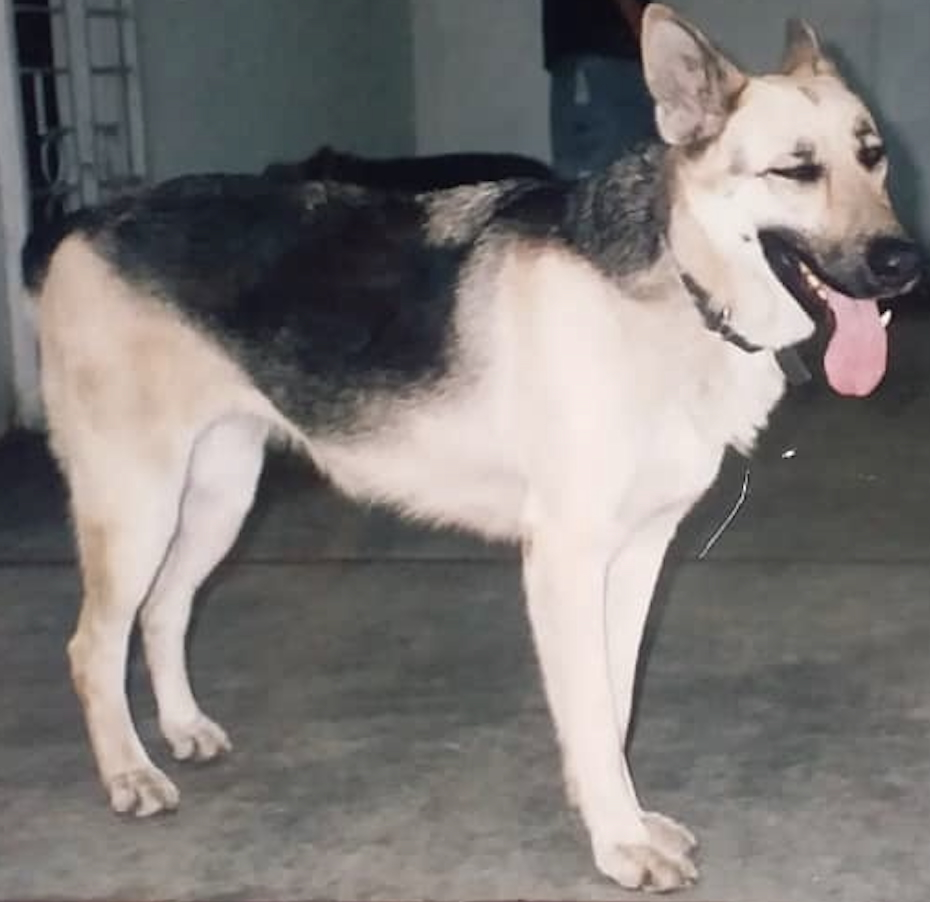

In [31]:
# Try exploring how the presence / absence of the background affects the model's predictions
# The cropped version includes background, the segmented version discards it
img_url = 'https://raw.githubusercontent.com/andandandand/images-for-colab-notebooks/refs/heads/main/rita_cropped.jpg'
#img_url = "https://raw.githubusercontent.com/andandandand/images-for-colab-notebooks/refs/heads/main/rita_segmented.jpg"
im_array = io.imread(img_url)
imag = Image.fromarray(im_array).convert('RGB')
imag

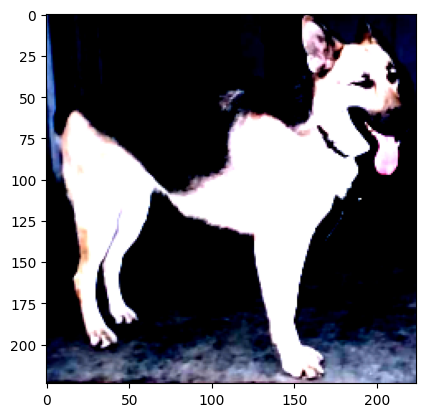

In [32]:
# How the network sees the image with Imagenet transforms
plt.imshow(val_test_transforms(imag).permute(1,2,0))

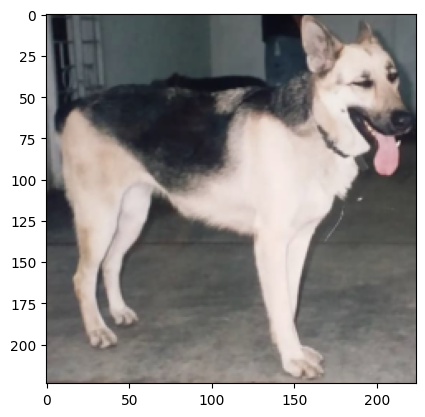

In [33]:
# Assuming 'imag' is your PIL Image and 'val_test_transforms' is your transformation
transformed_image = val_test_transforms(imag)

# Revert the normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
reverted_image = transformed_image.permute(1, 2, 0).numpy() * std + mean
reverted_image = np.clip(reverted_image, 0, 1)  # Clip values to be in [0, 1]

# Display the reverted image
plt.imshow(reverted_image)
plt.show()

In [34]:
imag.save('rita.jpg')

In [35]:
# Assuming you have a model loaded and 'rita.jpg' is your image
prediction = predict_image(model, 'rita.jpg', val_test_transforms)
predicted_label, predicted_prob = prediction
# The model is not robust against OOD samples
oxford_pets_classes[predicted_label], predicted_prob

(('American Pit Bull Terrier', 'dog'), 0.41325122117996216)

## Try a zero-shot classifier

In [36]:
# We can inspect the model's architecture, which is PyTorch code.
# We have downloaded both the architecture and the model's weights.
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [37]:
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
processor

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPProcessor:
- image_processor: CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

- tokenizer: CLIPTokenizerFast(name_or_path='openai/clip-vit-base-patch32', vocab_size=49408, model_max_length=77, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, spec

In [38]:
breed_labels.append("German Shepherd")
breed_labels.sort()

In [39]:
breed_labels

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shepherd',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

In [40]:

inputs = processor(text=breed_labels,
                   images=[imag],
                   return_tensors="pt", padding=True)
outputs = clip_model(**inputs)
logits_per_image = outputs.logits_per_image
temperature = 1.0
outputs.logits_per_image.shape

torch.Size([1, 38])

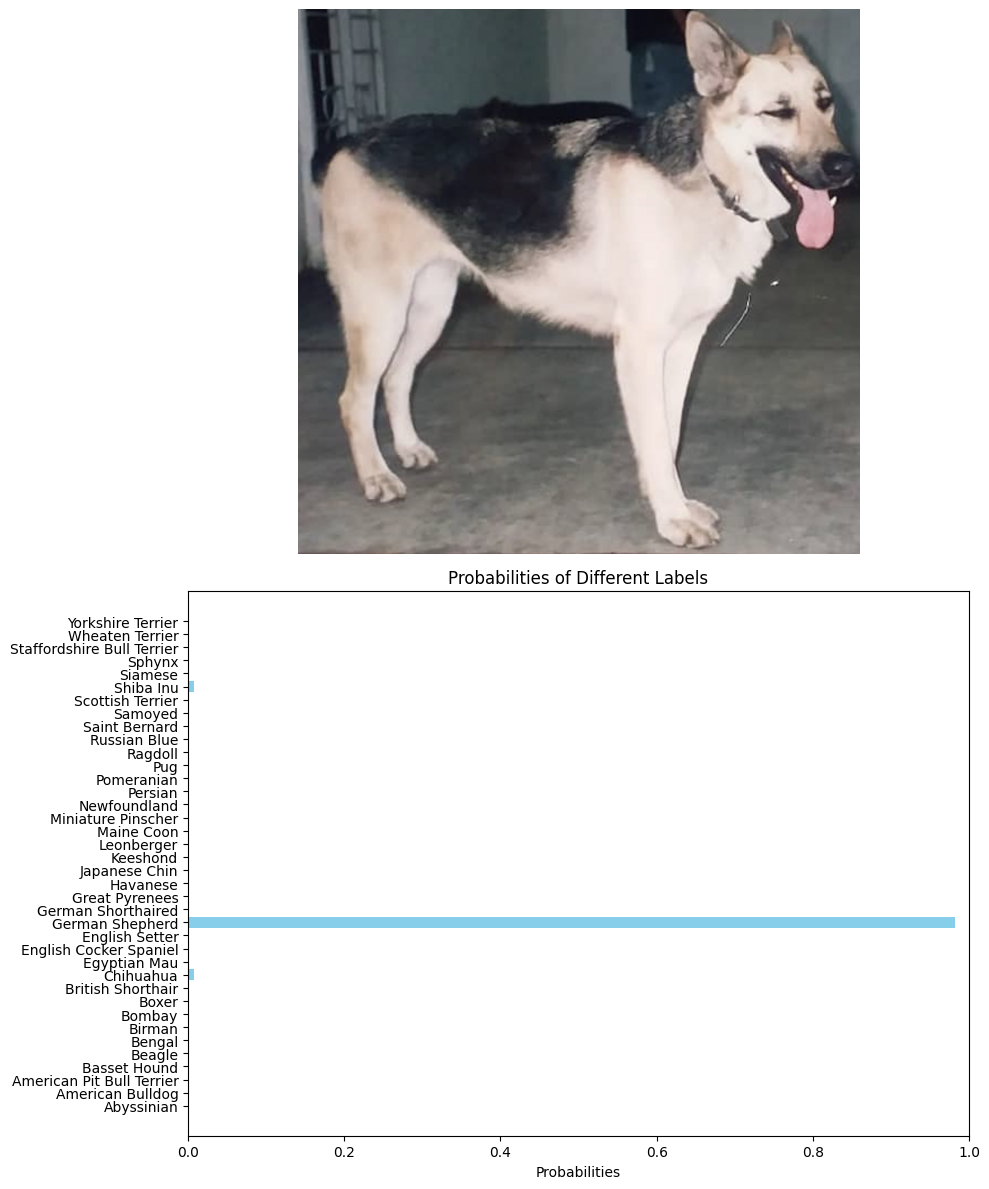

In [41]:
# Probabilities at different temperatures @title {run:'auto'}

slider_value = 0  # @param {type: "slider", min: 0, max: 5}
temperature = 0.7  # @param {type: "slider", min: 0, max: 2, step:0.1}

# Creating a subplot with an image in the first row and the histogram in the second row
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

axes[0].imshow(np.array(imag))
axes[0].axis('off')  # Turning off the axis for the image

probs = (logits_per_image/temperature).softmax(dim=1)

# Creating the horizontal bar plot in the second subplot
axes[1].barh(breed_labels, probs[slider_value].detach(), color='skyblue')
axes[1].set_xlim(0, 1)  # Setting the x-axis limit from 0 to 1

axes[1].set_xlabel('Probabilities')
axes[1].set_title('Probabilities of Different Labels')

plt.tight_layout()
plt.show()

## Create FiftyOne dataset with model predictions

FiftyOne needs to have image samples in the local file system. Our images are currently torch tensors, we convert them into PIL images and store them in the `data/test` folder to get them into FiftyOne.

In [42]:
# Create the 'data' folder if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

# Create the 'test' folder inside 'data' if it doesn't exist
if not os.path.exists('data/test'):
    os.makedirs('data/test')

In [43]:
def revert_imagenet_transforms(tensor):
  """Reverts the ImageNet transformations applied to a tensor.

  Args:
    tensor: A PyTorch float32 tensor with shape (C, H, W) that has been transformed using ImageNet normalization.

  Returns:
    A PyTorch float32 tensor with shape (C, H, W) in the range [0, 1].
  """
  # ImageNet mean and standard deviation
  imagenet_mean = np.array([0.485, 0.456, 0.406])
  imagenet_std = np.array([0.229, 0.224, 0.225])

  # Revert normalization
  reverted_tensor = tensor * torch.tensor(imagenet_std[:, None, None]).to(tensor.device) + torch.tensor(imagenet_mean[:, None, None]).to(tensor.device)

  # Clip values to [0, 1]
  reverted_tensor = torch.clamp(reverted_tensor, 0, 1)

  return reverted_tensor

In [44]:
def tensor_to_pil_image(tensor):
  """Converts a PyTorch float32 tensor to a PIL Image.

  Args:'
    tensor: A PyTorch float32 tensor with shape (C, H, W) in the range [0, 1].

  Returns:
    A PIL Image.
  """
  # Define the transformation to convert to PIL Image
  transform = transforms.ToPILImage()

  # Convert the tensor to a PIL Image
  image = transform(tensor)

  return image

In [45]:
true_labels = {}
predicted_labels = {}
predicted_probs = {}
for index, (tensor_imag, label) in tqdm(enumerate(test_dataset)):
    text_label = oxford_pets_classes[label][0]
    pil_imag = tensor_to_pil_image(revert_imagenet_transforms(tensor_imag))
    local_path = f'data/test/{text_label}_{index}.jpg'

    pil_imag.save(local_path)

    # Get predictions for the current image
    predicted_label, predicted_prob = predict_image(model, local_path, val_test_transforms)

    # Store labels and predictions in dictionaries
    true_labels[local_path] = text_label
    predicted_labels[local_path] = predicted_label
    predicted_probs[local_path] = predicted_prob



3669it [00:43, 84.81it/s]


In [46]:
# Delete the dataset if it exists
if fo.dataset_exists("pet_predictions"):
    fo.delete_dataset("pet_predictions")

# Create a new dataset
dataset = fo.Dataset("pet_predictions")

# Add samples to the dataset
for filepath, predicted_label in predicted_labels.items():
    sample = fo.Sample(filepath=filepath)

    # Add predicted label as a classification field
    sample["predicted_label"] = fo.Classification(
        label=oxford_pets_classes[predicted_label][0],
        confidence=predicted_probs[filepath]
    )

    # Add true label as a classification field
    sample["true_label"] = fo.Classification(
        label=true_labels[filepath],
        confidence=1.0
    )

    # Add a tag to indicate the image is part of the test set
    sample.tags.append("test sample")

    dataset.add_sample(sample)


# I want to label that the whole dataset is a test set
dataset.tags.append("test set")

# Persist the dataset to disk
dataset.persistent = True

# Print some info about the dataset
print(dataset)

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information


Name:        pet_predictions
Media type:  image
Num samples: 3669
Persistent:  True
Tags:        ['test set']
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    predicted_label:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    true_label:       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)


In [48]:
session = fo.launch_app(dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


https://5151-gpu-t4-hm-1z6auuuecolkv-a.asia-southeast1-1.prod.colab.dev?polling=true


## Suggested Exercises

1. Create a FiftyOne [`DatasetView`](https://docs.voxel51.com/user_guide/using_views.html) of all the misclassified images.
2. Extend the FiftyOne dataset with the images from the [Dogs vs Cats dataset on Kaggle](https://www.kaggle.com/c/dogs-vs-cats) and run your trained models on them.
3. Run a [zero-shot classifier](https://docs.voxel51.com/tutorials/zero_shot_classification.html) based on CLIP on the dogs vs cats dataset.
4. Compare our notebook with [Chapter 5 of the Deep Learning for Coders Book](https://github.com/fastai/fastbook/blob/master/05_pet_breeds.ipynb). How does the fastai approach compare with what we did with [cyclical learning rates](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.OneCycleLR.html)? What would you say is missing in this notebook vs their approach?
5. Can you think about strategies to correlate the background of the OOD image "Rita.jpg" with the labels belong to classes that **do not** look like German Shepherds in the training set?
6. How would you use [Class Activation Mapping](https://voxel51.com/blog/exploring-gradcam-and-more-with-fiftyone/) to interpret the results of the model?
7. Look into labeling the dataset [using variants of CLIP](https://docs.voxel51.com/tutorials/zero_shot_classification.html).
